<a href="https://colab.research.google.com/github/Vaishnavi02-01/seasonal-agriculture-performance-analysis/blob/main/MajorProject_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import scipy.stats as stats

In [20]:
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset (2).csv
User uploaded file "seasonal_agriculture_performance_dataset (2).csv" with length 669989 bytes


In [21]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
display(df.head())

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [22]:
print("Dataset Shape:", df.shape)
print("Missing values:", df.isnull().sum().to_dict())

Dataset Shape: (4000, 28)
Missing values: {'Farm_ID': 0, 'State': 0, 'District': 0, 'Crop': 0, 'Season': 0, 'Farm_Area_Hectares': 0, 'Rainfall_mm': 48, 'Avg_Temperature_C': 0, 'Humidity_pct': 0, 'Sunlight_Hours_Day': 0, 'Soil_pH': 0, 'Soil_Moisture_pct': 40, 'Nitrogen_kg_ha': 0, 'Phosphorus_kg_ha': 0, 'Potassium_kg_ha': 0, 'Irrigation_Method': 0, 'Fertilizer_kg_ha': 0, 'Pesticide_Litre_ha': 0, 'Seed_Quality_Score': 0, 'Yield_Tonnes_Ha': 32, 'Production_Tonnes': 0, 'Market_Price_INR_Tonne': 0, 'Total_Cost_INR': 0, 'Revenue_INR': 0, 'Profit_INR': 0, 'Water_Used_m3': 0, 'Water_Efficiency_t_per_1000m3': 0, 'Disease_Pest_Risk_pct': 0}


In [23]:
# Clean missing values for statistical modeling
df_clean = df.dropna(subset=['Yield_Tonnes_Ha', 'Rainfall_mm', 'Profit_INR'])

In [24]:
# One-Way ANOVA: Profit across Seasons (Kharif, Rabi, Zaid)
kharif_p = df_clean[df_clean['Season'] == 'Kharif']['Profit_INR']
rabi_p = df_clean[df_clean['Season'] == 'Rabi']['Profit_INR']
zaid_p = df_clean[df_clean['Season'] == 'Zaid']['Profit_INR']
anova_season = stats.f_oneway(kharif_p, rabi_p, zaid_p)

In [26]:
# One-Way ANOVA: Profit across Irrigation Methods
drip_p = df_clean[df_clean['Irrigation_Method'] == 'Drip']['Profit_INR']
flood_p = df_clean[df_clean['Irrigation_Method'] == 'Flood']['Profit_INR']
sprinkler_p = df_clean[df_clean['Irrigation_Method'] == 'Sprinkler']['Profit_INR']
rainfed_p = df_clean[df_clean['Irrigation_Method'] == 'Rainfed']['Profit_INR']
anova_irrigation = stats.f_oneway(drip_p, flood_p, sprinkler_p, rainfed_p)

print(f"ANOVA (Season vs Profit) -> F-statistic: {anova_season.statistic:.2f}, p-value: {anova_season.pvalue:.4e}")
print(f"ANOVA (Irrigation vs Profit) -> F-statistic: {anova_irrigation.statistic:.2f}, p-value: {anova_irrigation.pvalue:.4e}")

ANOVA (Season vs Profit) -> F-statistic: 35.64, p-value: 4.5743e-16
ANOVA (Irrigation vs Profit) -> F-statistic: 14.82, p-value: 1.3560e-09


In [16]:
# Calculate operational performance metrics
kpi_summary = pd.DataFrame({
    'Metric': ['Total Farms Evaluated', 'Mean Yield (Tonnes/Ha)', 'Mean Profit (INR)', 'Drip Irrigation Profit', 'Flood Irrigation Profit'],
    'Value': [
        len(df_clean),
        f"{df_clean['Yield_Tonnes_Ha'].mean():.2f}",
        f"INR {df_clean['Profit_INR'].mean():,.2f}",
        f"INR {df_clean[df_clean['Irrigation_Method'] == 'Drip']['Profit_INR'].mean():,.2f}",
        f"INR {df_clean[df_clean['Irrigation_Method'] == 'Flood']['Profit_INR'].mean():,.2f}"
    ]
})
print(kpi_summary.to_string(index=False))

                 Metric          Value
  Total Farms Evaluated           3920
 Mean Yield (Tonnes/Ha)           5.26
      Mean Profit (INR) INR 111,974.78
 Drip Irrigation Profit INR 216,961.21
Flood Irrigation Profit  INR 73,797.98


In [17]:
# Ordinary Least Squares Regression examining Profit drivers
ols_model = smf.ols('Profit_INR ~ Yield_Tonnes_Ha + Water_Used_m3 + Total_Cost_INR + Fertilizer_kg_ha + Disease_Pest_Risk_pct', data=df_clean).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:             Profit_INR   R-squared:                       0.256
Model:                            OLS   Adj. R-squared:                  0.255
Method:                 Least Squares   F-statistic:                     268.7
Date:                Wed, 09 Sep 2026   Prob (F-statistic):          1.21e-247
Time:                        14:38:25   Log-Likelihood:                -56773.
No. Observations:                3920   AIC:                         1.136e+05
Df Residuals:                    3914   BIC:                         1.136e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept             -3.472e+

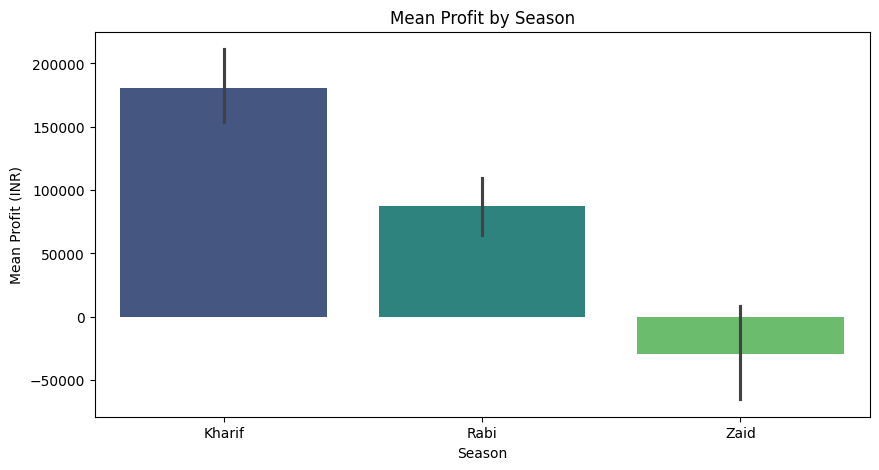

In [13]:
# Chart 1: Mean Profit by Season
plt.figure(figsize=(10, 5))
sns.barplot(x='Season', y='Profit_INR', data=df_clean, estimator='mean', hue='Season', palette='viridis', order=['Kharif', 'Rabi', 'Zaid'])
plt.title('Mean Profit by Season')
plt.xlabel('Season')
plt.ylabel('Mean Profit (INR)')
plt.show()

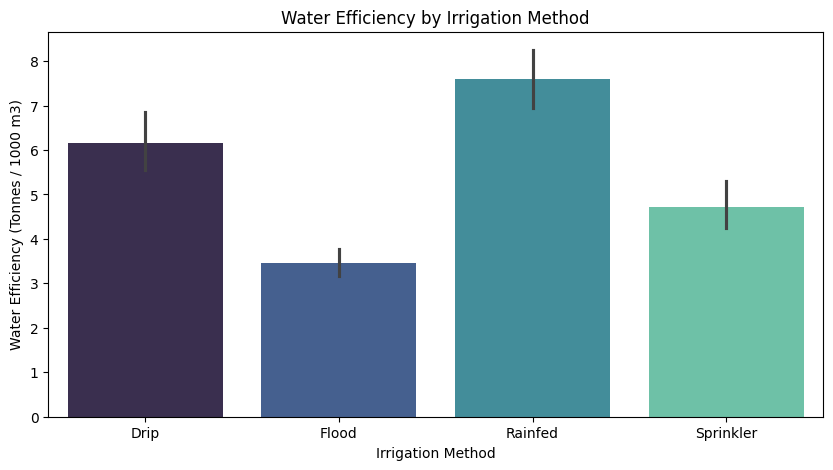

In [14]:
# Chart 2: Water Efficiency by Irrigation Method
plt.figure(figsize=(10, 5))
sns.barplot(x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', data=df_clean, estimator='mean', hue='Irrigation_Method', palette='mako')
plt.title('Water Efficiency by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Water Efficiency (Tonnes / 1000 m3)')
plt.show()

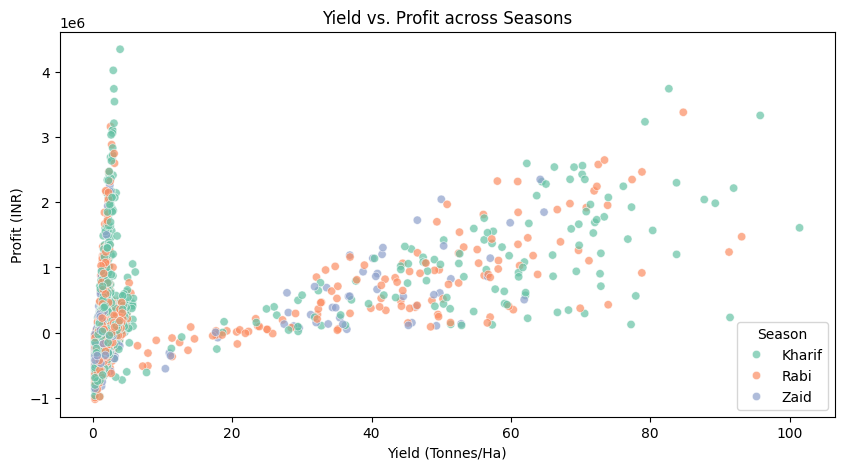

In [15]:
# Chart 3: Yield vs Profit Scatterplot
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Yield_Tonnes_Ha', y='Profit_INR', hue='Season', data=df_clean, palette='Set2', alpha=0.7)
plt.title('Yield vs. Profit across Seasons')
plt.xlabel('Yield (Tonnes/Ha)')
plt.ylabel('Profit (INR)')
plt.show()

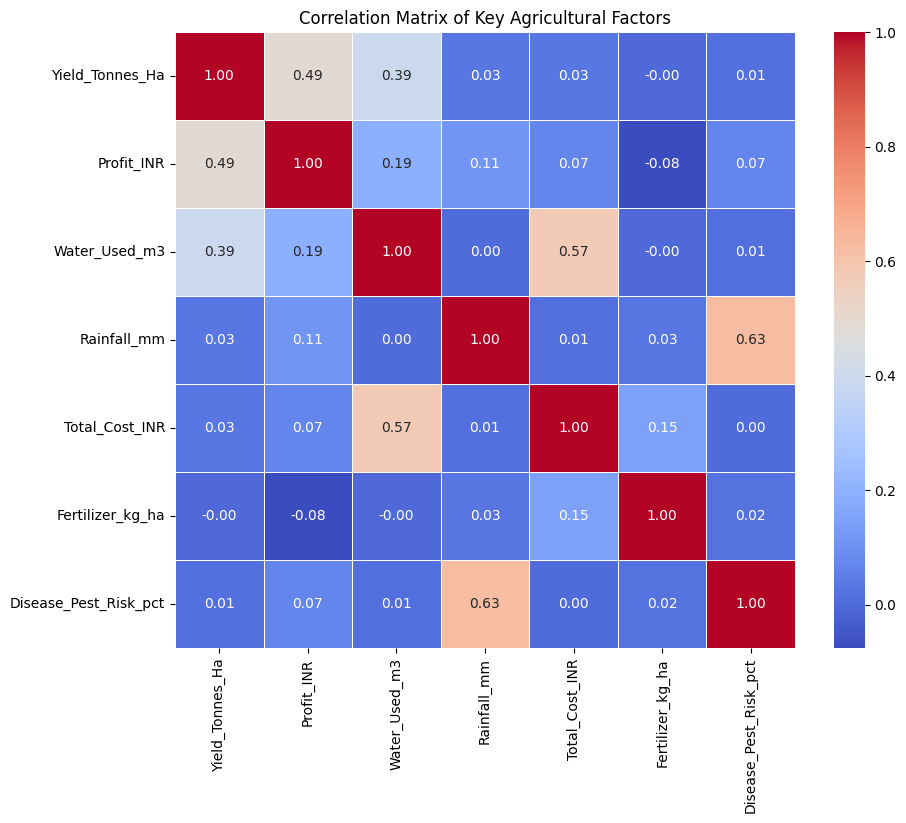

In [27]:
# Select key numerical features for correlation analysis
num_cols = [
    'Yield_Tonnes_Ha',
    'Profit_INR',
    'Water_Used_m3',
    'Rainfall_mm',
    'Total_Cost_INR',
    'Fertilizer_kg_ha',
    'Disease_Pest_Risk_pct'
]

# Compute correlation matrix
corr_matrix = df_clean[num_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Key Agricultural Factors')
plt.show()